In [11]:
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

s = smape(df_test['quantidade'], forecast_df['quantidade'])
print(f"SMAPE: {s:.2f}%")


SMAPE: 33.97%


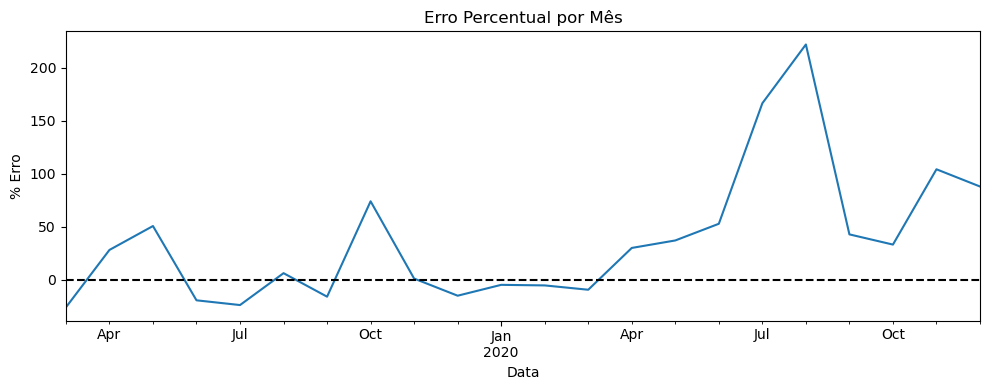

In [13]:
erro_percentual = (forecast_df['quantidade'] - df_test['quantidade']) / df_test['quantidade'] * 100
erro_percentual.plot(figsize=(10,4), title="Erro Percentual por Mês")
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('% Erro')
plt.xlabel('Data')
plt.tight_layout()
plt.show()


In [15]:
# Substituir 2020 e 2021 por NaN
df.loc[df.index.year.isin([2020, 2021]), 'quantidade'] = np.nan

# Interpolar os valores ausentes (linearmente entre 2019 e 2022, por exemplo)
df['quantidade'] = df['quantidade'].interpolate(method='linear')


In [27]:
import pandas as pd

# ---------------------
# 1. Carregar os dados originais e agrupar por mês
# ---------------------
df = pd.read_csv('transplantes_diarios.csv', parse_dates=['data'], index_col='data')
df = df.resample('M').sum()

# ---------------------
# 2. Remover registros com zero ou NaN
# ---------------------
df = df[df['quantidade'] > 0]

# ---------------------
# 3. Adicionar colunas auxiliares de mês e ano
# ---------------------
df['mes'] = df.index.month
df['ano'] = df.index.year

# ---------------------
# 4. Calcular a média de cada mês (apenas até 2019)
# ---------------------
medias_mensais = df[df['ano'] < 2020].groupby('mes')['quantidade'].mean()

# ---------------------
# 5. Substituir os valores de 2020 e 2021 pela média mensal
# ---------------------
for ano in [2020, 2021]:
    for mes in range(1, 13):
        data_alvo = pd.Timestamp(f'{ano}-{mes:02d}-01') + pd.offsets.MonthEnd(0)
        if data_alvo in df.index:
            df.loc[data_alvo, 'quantidade'] = medias_mensais[mes]

# ---------------------
# 6. Remover colunas auxiliares
# ---------------------
df = df[['quantidade']]

# ---------------------
# 7. Salvar de volta com o mesmo nome
# ---------------------
df.to_csv('transplantes_diarios.csv')
print(" CSV atualizado e salvo com sucesso!")


 CSV atualizado e salvo com sucesso!


C:\Users\figue\AppData\Local\Temp\ipykernel_3296\2498257297.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample('M').sum()
C:\Users\figue\AppData\Local\Temp\ipykernel_3296\2498257297.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '42.916666666666664' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[data_alvo, 'quantidade'] = medias_mensais[mes]


ADF Statistic: -2.608041247370841
p-value: 0.09134666826618743
Critical Values: {'1%': -3.4782936965183815, '5%': -2.882567574015525, '10%': -2.5779830117488745}
A série não é estacionária.
MAE (treino): 7.70
RMSE (treino): 9.68


C:\Users\figue\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\figue\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         quantidade   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -425.007
Date:                            Sat, 19 Apr 2025   AIC                            860.014
Time:                                    08:01:53   BIC                            873.825
Sample:                                01-31-2008   HQIC                           865.621
                                     - 12-31-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0903      0.116      0.780      0.435      -0.137       0.317
ma.L1         -0.8758      0.057   

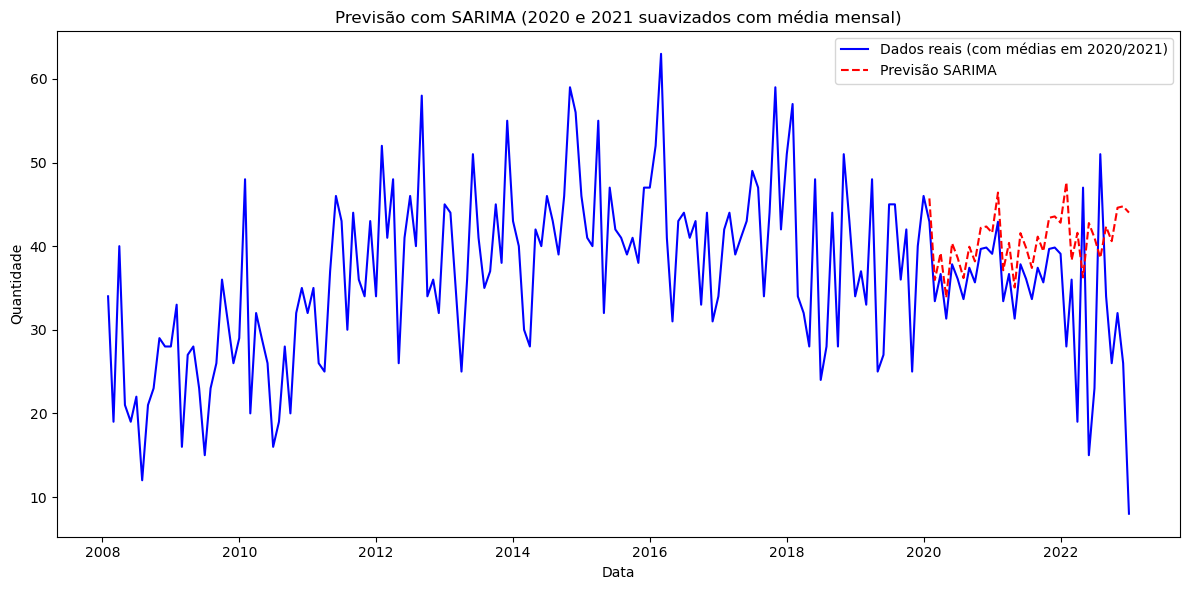

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ---------------------
# 1. Carregar os dados tratados
# ---------------------
df = pd.read_csv('transplantes_diarios.csv', parse_dates=['data'], index_col='data')
df = df.sort_index()

# ---------------------
# 2. Teste de estacionariedade (ADF)
# ---------------------
def test_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:', result[4])
    if result[1] <= 0.05:
        print("A série é estacionária.")
    else:
        print("A série não é estacionária.")

# ---------------------
# 3. Dividir em treino e teste
# ---------------------
split_index = int(len(df) * 0.8)
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

# ---------------------
# 4. Testar estacionariedade no treino
# ---------------------
test_stationarity(df_train['quantidade'])

# ---------------------
# Avaliação no treino
# ---------------------
train_pred = model_fit.fittedvalues
mae_train = mean_absolute_error(df_train['quantidade'], train_pred)
rmse_train = np.sqrt(mean_squared_error(df_train['quantidade'], train_pred))

print(f"MAE (treino): {mae_train:.2f}")
print(f"RMSE (treino): {rmse_train:.2f}")
# ---------------------
# 5. Ajustar modelo SARIMA
# ---------------------
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

model = SARIMAX(
    df_train['quantidade'],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()
print(model_fit.summary())

# ---------------------
# 6. Previsão
# ---------------------
forecast = model_fit.forecast(steps=len(df_test))
forecast_df = pd.DataFrame({'quantidade': forecast}, index=df_test.index)

# ---------------------
# 7. Avaliação (remover NaNs, se houver)
# ---------------------
df_test_aligned, forecast_aligned = df_test.align(forecast_df, join='inner')
mask = (~df_test_aligned['quantidade'].isna()) & (~forecast_aligned['quantidade'].isna())

mae = mean_absolute_error(df_test_aligned['quantidade'][mask], forecast_aligned['quantidade'][mask])
rmse = np.sqrt(mean_squared_error(df_test_aligned['quantidade'][mask], forecast_aligned['quantidade'][mask]))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# SMAPE
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

s = smape(df_test_aligned['quantidade'][mask], forecast_aligned['quantidade'][mask])
print(f"SMAPE: {s:.2f}%")

# ---------------------
# 8. Gráfico final
# ---------------------
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['quantidade'], label='Dados reais (com médias em 2020/2021)', color='blue')
plt.plot(forecast_df.index, forecast_df['quantidade'], label='Previsão SARIMA', color='red', linestyle='dashed')
plt.xlabel('Data')
plt.ylabel('Quantidade')
plt.title('Previsão com SARIMA (2020 e 2021 suavizados com média mensal)')
plt.legend()
plt.tight_layout()
plt.show()


ADF Statistic: -2.8381185870354364
p-value: 0.05303171206143427
Critical Values: {'1%': np.float64(-3.4318527927183196), '5%': np.float64(-2.86220405019551), '10%': np.float64(-2.5671234784459993)}
A série não é estacionária.


/home/isadora/ic/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/isadora/ic/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                    Qtd_Procedimentos   No. Observations:                 4382
Model:             SARIMAX(1, 1, 2)x(1, 1, [1], 12)   Log Likelihood              -19161.271
Date:                              Sat, 19 Jul 2025   AIC                          38334.541
Time:                                      14:39:27   BIC                          38372.814
Sample:                                  01-01-2008   HQIC                         38348.050
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7101      0.050     14.097      0.000       0.611       0.809
ma.L1         -2.01

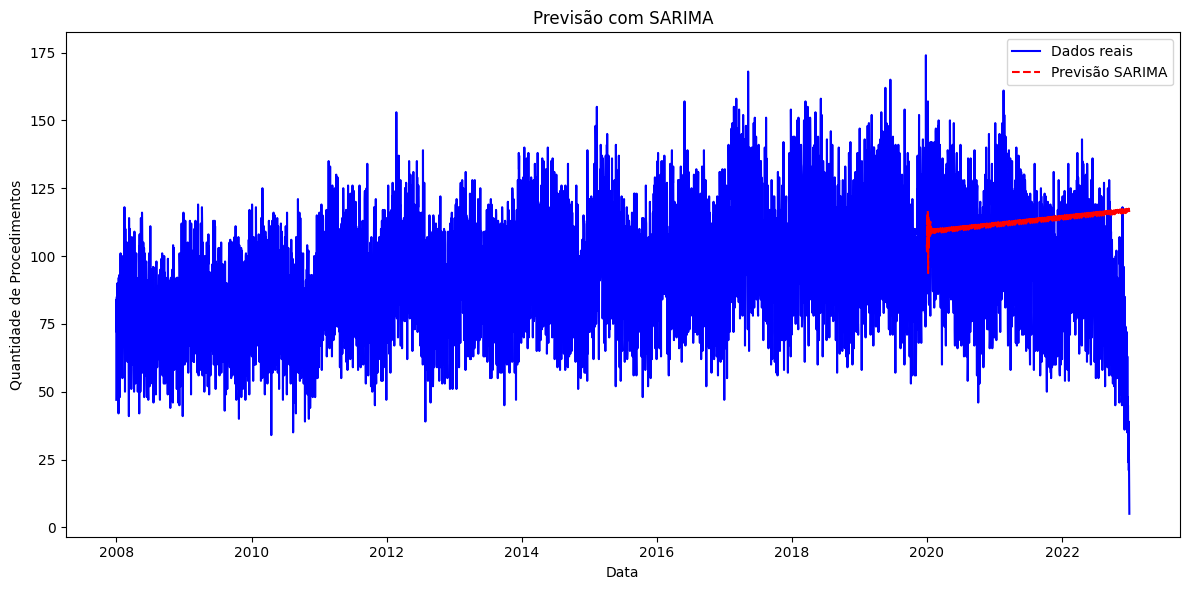

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ---------------------
# 1. Carregar os dados tratados
# ---------------------
df = pd.read_csv('parto_dia_15.csv', parse_dates=['DT_INTER'], index_col='DT_INTER')
df = df.sort_index()

# ---------------------
# 2. Teste de estacionariedade (ADF)
# ---------------------
def test_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:', result[4])
    if result[1] <= 0.05:
        print("A série é estacionária.")
    else:
        print("A série não é estacionária.")

# ---------------------
# 3. Dividir em treino e teste
# ---------------------
split_index = int(len(df) * 0.8)
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

# ---------------------
# 4. Testar estacionariedade no treino
# ---------------------
test_stationarity(df_train['Qtd_Procedimentos'])

# ---------------------
# 5. Ajustar modelo SARIMA
# ---------------------
order = (1, 1, 2)
seasonal_order = (1, 1, 1, 12)

model = SARIMAX(
    df_train['Qtd_Procedimentos'], # Alterado para a nova coluna
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()
print(model_fit.summary())

# ---------------------
# Avaliação no treino
# ---------------------
train_pred = model_fit.fittedvalues
mae_train = mean_absolute_error(df_train['Qtd_Procedimentos'], train_pred) # Alterado para a nova coluna
rmse_train = np.sqrt(mean_squared_error(df_train['Qtd_Procedimentos'], train_pred)) # Alterado para a nova coluna

print(f"MAE (treino): {mae_train:.2f}")
print(f"RMSE (treino): {rmse_train:.2f}")

# ---------------------
# 6. Previsão
# ---------------------
forecast = model_fit.forecast(steps=len(df_test))
forecast_df = pd.DataFrame({'Qtd_Procedimentos': forecast}, index=df_test.index) # Alterado para a nova coluna

# ---------------------
# 7. Avaliação (remover NaNs, se houver)
# ---------------------
df_test_aligned, forecast_aligned = df_test.align(forecast_df, join='inner')
mask = (~df_test_aligned['Qtd_Procedimentos'].isna()) & (~forecast_aligned['Qtd_Procedimentos'].isna()) # Alterado para a nova coluna

mae = mean_absolute_error(df_test_aligned['Qtd_Procedimentos'][mask], forecast_aligned['Qtd_Procedimentos'][mask]) # Alterado para a nova coluna
rmse = np.sqrt(mean_squared_error(df_test_aligned['Qtd_Procedimentos'][mask], forecast_aligned['Qtd_Procedimentos'][mask])) # Alterado para a nova coluna
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# SMAPE
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

s = smape(df_test_aligned['Qtd_Procedimentos'][mask], forecast_aligned['Qtd_Procedimentos'][mask]) # Alterado para a nova coluna
print(f"SMAPE: {s:.2f}%")

# ---------------------
# 8. Gráfico final
# ---------------------
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Qtd_Procedimentos'], label='Dados reais', color='blue') # Alterado para a nova coluna
plt.plot(forecast_df.index, forecast_df['Qtd_Procedimentos'], label='Previsão SARIMA', color='red', linestyle='dashed') # Alterado para a nova coluna
plt.xlabel('Data')
plt.ylabel('Quantidade de Procedimentos') # Alterado o rótulo do eixo Y
plt.title('Previsão com SARIMA') # Alterado o título
plt.legend()
plt.tight_layout()
plt.show()

ADF Statistic: -2.722114095095401
p-value: 0.07028911464235867
Critical Values: {'1%': -3.4753253063120644, '5%': -2.881274703275226, '10%': -2.5772928360116873}
A série não é estacionária.
                                     SARIMAX Results                                      
Dep. Variable:                         quantidade   No. Observations:                  153
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -454.198
Date:                            Sat, 19 Apr 2025   AIC                            918.397
Time:                                    10:01:58   BIC                            932.578
Sample:                                01-01-2008   HQIC                           924.158
                                     - 09-01-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---

/home/isadora/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/isadora/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE: 6.45
RMSE: 9.18
SMAPE: 18.45%


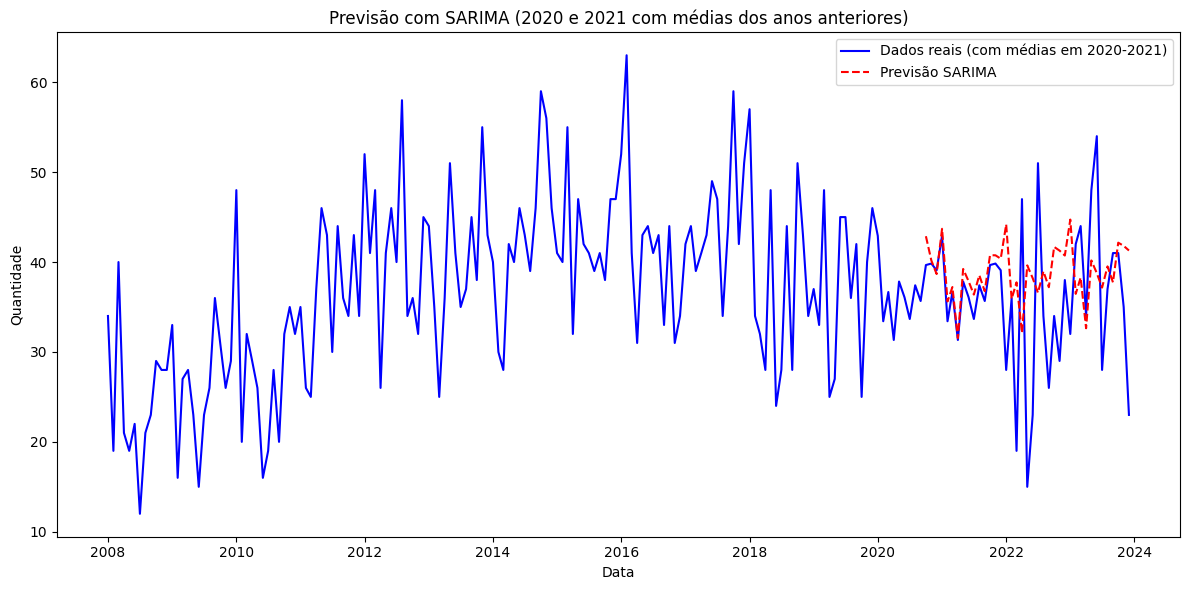

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ---------------------
# 1. Carregar e preparar os dados
# ---------------------
df = pd.read_csv('transplantes_mes.csv')

# Converte para datetime e ordena
df['data'] = pd.to_datetime(df['data'], format='%m/%Y')
df = df.set_index('data').sort_index()

# Extrai mês e ano
df['mes'] = df.index.month
df['ano'] = df.index.year

# ---------------------
# 2. Substituir 2020 e 2021 pelas médias dos meses anteriores
# ---------------------
# Cria cópia e remove valores de 2020 e 2021
df_corrigido = df.copy()
df_corrigido.loc[df_corrigido['ano'].isin([2020, 2021]), 'quantidade'] = np.nan

# Para cada mês de 2020 e 2021, calcula a média dos mesmos meses de anos anteriores
for ano in [2020, 2021]:
    for mes in range(1, 13):
        media = df_corrigido[(df_corrigido['mes'] == mes) & (df_corrigido['ano'] < 2020)]['quantidade'].mean()
        df_corrigido.loc[(df_corrigido['ano'] == ano) & (df_corrigido['mes'] == mes), 'quantidade'] = media

# ---------------------
# 3. Dividir treino e teste
# ---------------------
split_index = int(len(df_corrigido) * 0.8)
df_train = df_corrigido.iloc[:split_index]
df_test = df_corrigido.iloc[split_index:]

# ---------------------
# 4. Teste de estacionariedade
# ---------------------
def test_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:', result[4])
    if result[1] <= 0.05:
        print("A série é estacionária.")
    else:
        print("A série não é estacionária.")

test_stationarity(df_train['quantidade'])

# ---------------------
# 5. Ajustar o modelo SARIMA
# ---------------------
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

model = SARIMAX(
    df_train['quantidade'],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit()
print(model_fit.summary())

# ---------------------
# 6. Previsão
# ---------------------
forecast = model_fit.forecast(steps=len(df_test))
forecast_df = pd.DataFrame({'quantidade': forecast}, index=df_test.index)

# ---------------------
# 7. Avaliação do modelo
# ---------------------
mae = mean_absolute_error(df_test['quantidade'], forecast_df['quantidade'])
rmse = np.sqrt(mean_squared_error(df_test['quantidade'], forecast_df['quantidade']))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

s = smape(df_test['quantidade'], forecast_df['quantidade'])
print(f"SMAPE: {s:.2f}%")

# ---------------------
# 8. Gráfico final
# ---------------------
plt.figure(figsize=(12, 6))

plt.plot(df_corrigido.index, df_corrigido['quantidade'], label='Dados reais (com médias em 2020-2021)', color='blue')
plt.plot(forecast_df.index, forecast_df['quantidade'], label='Previsão SARIMA', color='red', linestyle='dashed')
plt.legend()
plt.xlabel('Data')
plt.ylabel('Quantidade')
plt.title('Previsão com SARIMA (2020 e 2021 com médias dos anos anteriores)')
plt.tight_layout()
plt.savefig("preditivo_transplante.png", dpi=300, bbox_inches='tight')
plt.show()



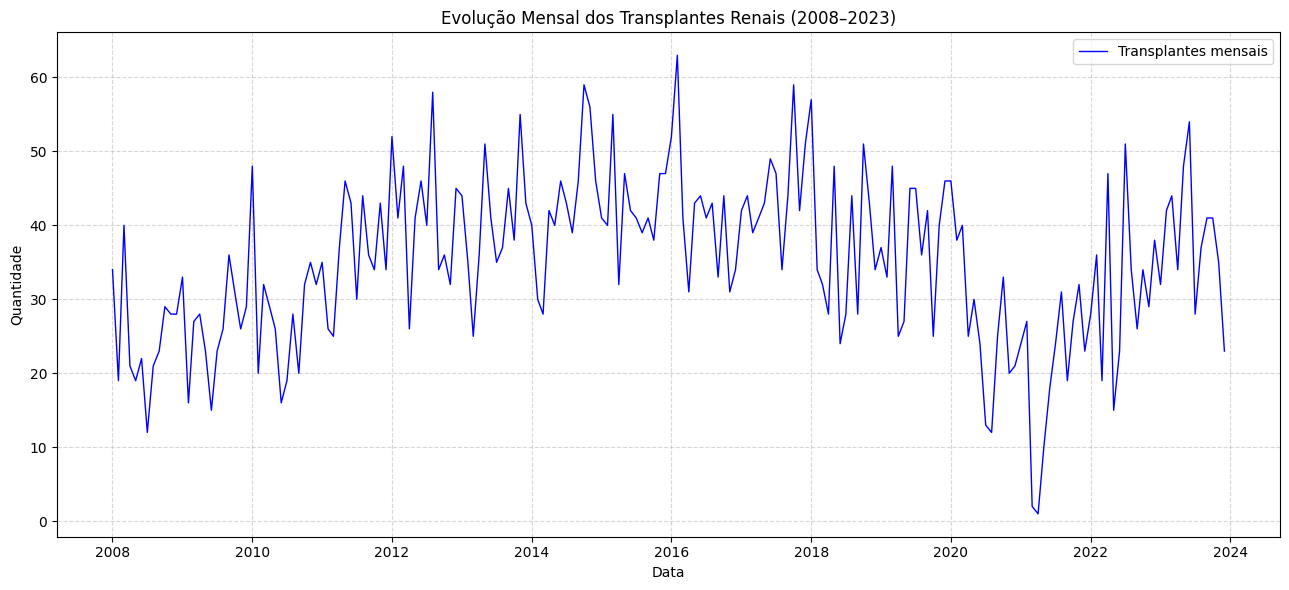

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Carrega os dados mensais
df = pd.read_csv('transplantes_mes.csv')

# Converte 'data' para datetime e ordena
df['data'] = pd.to_datetime(df['data'], format='%m/%Y')
df = df.set_index('data').sort_index()

# Plotando a linha original da quantidade mensal
plt.figure(figsize=(13, 6))
plt.plot(df.index, df['quantidade'], color='blue', linewidth=1, label='Transplantes mensais')
plt.title("Evolução Mensal dos Transplantes Renais (2008–2023)")
plt.xlabel("Data")
plt.ylabel("Quantidade")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("transplante_tendencia.png", dpi=300, bbox_inches='tight')
plt.show()


Carregando e preparando os dados do arquivo: partos_dia.csv
Nomes das colunas após limpeza:
['DT_INTER', 'QTD_PARTOS_NO_DIA']
Dados carregados. Total de registros: 6,346
Primeiras 5 linhas do DataFrame preparado:
            QTD_PARTOS_NO_DIA
DT_INTER                     
2007-07-30                  1
2007-07-31                  1
2007-08-01                  3
2007-08-02                  1
2007-08-04                  1

Filtrando dados para o período de 2008 até o final de 2020...
Dados filtrados. Total de registros: 5,479

Agrupando dados por mês...
Dados agrupados por mês. Total de registros mensais: 180
Primeiras 5 linhas do DataFrame mensal:
            QTD_PARTOS_NO_DIA
DT_INTER                     
2008-01-31               2318
2008-02-29               2441
2008-03-31               2462
2008-04-30               2386
2008-05-31               2480

Divisão Treino/Teste:
Tamanho do conjunto de treino: 153 registros
Tamanho do conjunto de teste: 27 registros
Período de treino: 2008-0

/tmp/ipykernel_6653/2514176337.py:68: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensal = df[coluna_quantidade].resample('M').sum().to_frame()


Modelo ajustado com sucesso!
                                        SARIMAX Results                                        
Dep. Variable:                       QTD_PARTOS_NO_DIA   No. Observations:                  153
Model:             SARIMAX(1, 1, 1)x(1, 1, [1, 2], 12)   Log Likelihood                -714.208
Date:                                 Sat, 19 Jul 2025   AIC                           1440.416
Time:                                         14:41:13   BIC                           1456.833
Sample:                                     01-31-2008   HQIC                          1447.079
                                          - 09-30-2020                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3211      0.157      2.045  

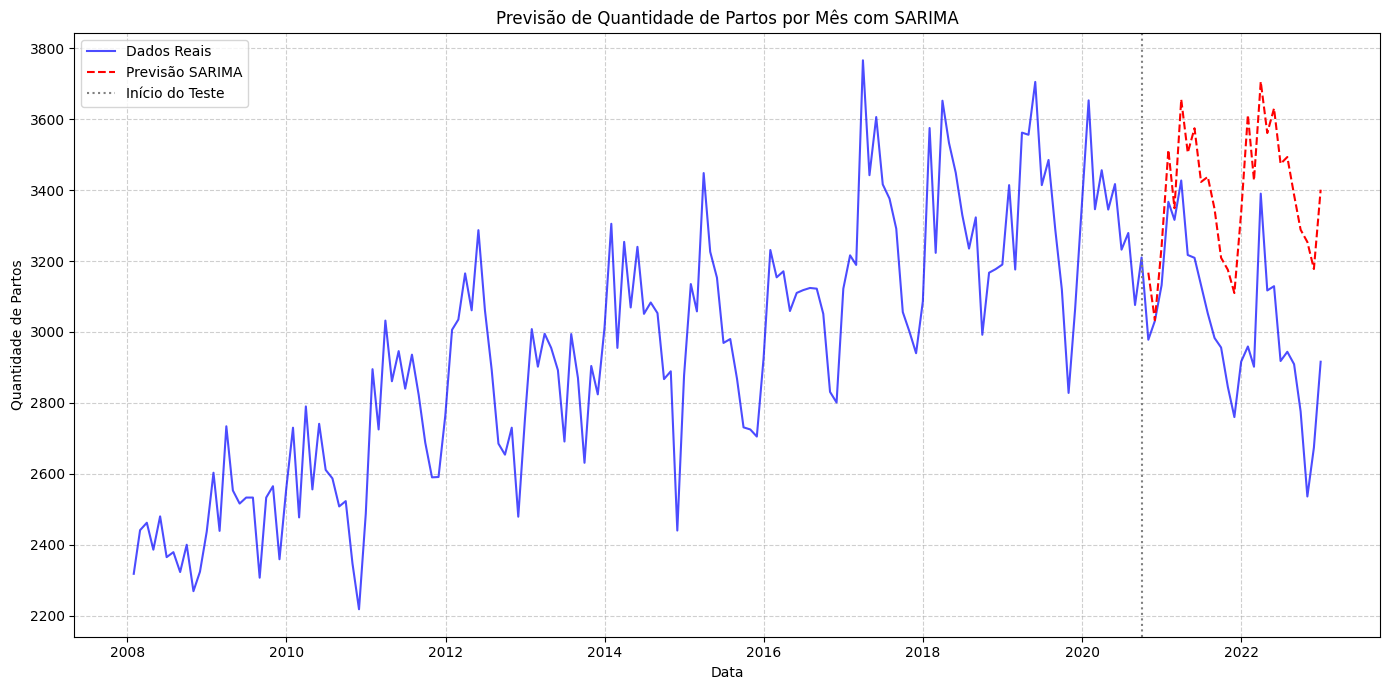


Execução do modelo preditivo concluída.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import os

# --- Configurações ---
# Caminho para o arquivo CSV de partos por dia
caminho_csv_partos = 'partos_dia.csv'
# Coluna de data no CSV de partos
coluna_data = 'DT_INTER' # Nome esperado da coluna de data
# Coluna de quantidade no CSV de partos
coluna_quantidade = 'QTD_PARTOS_NO_DIA'
# Nome do arquivo para salvar o gráfico
nome_arquivo_grafico = "preditivo_partos_mes_ajustado.png" # Alterado para refletir novo ajuste

# ---------------------
# 1. Carregar e preparar os dados
# ---------------------
print(f"Carregando e preparando os dados do arquivo: {caminho_csv_partos}")
if not os.path.exists(caminho_csv_partos):
    print(f"Erro: O arquivo '{caminho_csv_partos}' não foi encontrado.")
    print("Certifique-se de que o arquivo está na mesma pasta do script.")
    exit()

df = pd.read_csv(caminho_csv_partos)

# --- Ajuste CRÍTICO: Limpar nomes das colunas ---
# Isso remove espaços em branco (ou outros caracteres invisíveis) dos nomes das colunas
# que podem causar o KeyError.
df.columns = df.columns.str.strip()
print("Nomes das colunas após limpeza:")
print(df.columns.tolist())

# Converte a coluna de data para datetime e define como índice
# O formato da data no 'partos_dia.csv' é 'YYYY-MM-DD', então usamos '%Y-%m-%d'
df[coluna_data] = pd.to_datetime(df[coluna_data], format='%Y-%m-%d', errors='coerce')
df = df.set_index(coluna_data).sort_index()

# Remove linhas com datas inválidas (NaT) que podem ter surgir da conversão
if coluna_quantidade in df.columns:
    df = df.dropna(subset=[coluna_quantidade])
else:
    print(f"Aviso: Coluna '{coluna_quantidade}' não encontrada para remoção de NaNs.")

# Garante que o índice (coluna de data) não tem NaNs.
# Isso é importante para séries temporais.
df = df[df.index.notna()]

# Garante que a coluna de quantidade é numérica
df[coluna_quantidade] = pd.to_numeric(df[coluna_quantidade], errors='coerce')
df = df.dropna(subset=[coluna_quantidade]) # Remove NaNs que podem ter surgido da conversão

print(f"Dados carregados. Total de registros: {len(df):,}")
print("Primeiras 5 linhas do DataFrame preparado:")
print(df.head().to_string())

# --- NOVO AJUSTE: Filtrar dados por período (2008 até o final de 2020) ---
print("\nFiltrando dados para o período de 2008 até o final de 2020...")
df = df.loc['2008-01-01':'2022-12-31'] # Alterado o limite superior para 2020-12-31
print(f"Dados filtrados. Total de registros: {len(df):,}")

# --- NOVO AJUSTE: Agrupar dados por mês ---
print("\nAgrupando dados por mês...")
# Resample 'M' para o final do mês e soma as quantidades
df_mensal = df[coluna_quantidade].resample('M').sum().to_frame()
df_mensal.columns = [coluna_quantidade] # Renomeia a coluna após resample
print(f"Dados agrupados por mês. Total de registros mensais: {len(df_mensal):,}")
print("Primeiras 5 linhas do DataFrame mensal:")
print(df_mensal.head().to_string())

# Usaremos df_mensal para o restante do pipeline
df = df_mensal

# ---------------------
# 2. Não é necessária correção de dados para 2020 e 2021,
#    pois o objetivo é prever a série original de partos.
#    Esta seção foi removida do modelo original de transplantes.
# ---------------------

# ---------------------
# 3. Dividir treino e teste
# ---------------------
# Usar os últimos 12 meses (ou um período sazonal) como conjunto de teste é uma boa prática
# para séries temporais com sazonalidade mensal (12).
# Se a série for diária, o período de teste pode ser os últimos 30, 60 ou 90 dias, por exemplo.
# Para este exemplo, vamos usar os últimos 12 meses como teste.
# Ajuste conforme a granularidade da sua série e o período que deseja prever.

# NOVO AJUSTE: Aumentar a base de treino para 85%
split_index = int(len(df) * 0.85) # Alterado para 85%
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

print(f"\nDivisão Treino/Teste:")
print(f"Tamanho do conjunto de treino: {len(df_train):,} registros")
print(f"Tamanho do conjunto de teste: {len(df_test):,} registros")
print(f"Período de treino: {df_train.index.min().strftime('%Y-%m-%d')} a {df_train.index.max().strftime('%Y-%m-%d')}")
print(f"Período de teste: {df_test.index.min().strftime('%Y-%m-%d')} a {df_test.index.max().strftime('%Y-%m-%d')}")


# ---------------------
# 4. Teste de estacionariedade (ADF - Augmented Dickey-Fuller)
# ---------------------
# É importante que a série seja estacionária para modelos SARIMA.
# Se p-value > 0.05, a série não é estacionária e pode precisar de diferenciação (d ou D).
def test_stationarity(timeseries):
    print("\nRealizando Teste de Estacionariedade (Augmented Dickey-Fuller):")
    result = adfuller(timeseries.dropna()) # .dropna() para lidar com possíveis NaNs
    print('Estatística ADF:', result[0])
    print('p-value:', result[1])
    print('Valores Críticos:', result[4])
    if result[1] <= 0.05:
        print("A série é estacionária (p-value <= 0.05).")
    else:
        print("A série não é estacionária (p-value > 0.05). Pode ser necessária diferenciação.")

test_stationarity(df_train[coluna_quantidade])

# ---------------------
# 5. Ajustar o modelo SARIMA
# ---------------------
# Os parâmetros (p,d,q)(P,D,Q,s) são cruciais.
# (p,d,q): ordem não sazonal (AR, I, MA)
# (P,D,Q,s): ordem sazonal (AR, I, MA, período sazonal)

# NOVO AJUSTE: Parâmetros para dados MENSAIS (s=12)
# Tentando (p=1, d=1, q=1) e (P=1, D=1, Q=2, s=12)
order = (1, 1, 1)        # (p, d, q) - Voltando a q=1
seasonal_order = (1, 1, 2, 12) # (P, D, Q, s) - Aumentando Q para 2

# Se o p-value do teste ADF foi alto, considere aumentar 'd' em 'order' ou 'D' em 'seasonal_order'.
# enforce_stationarity e enforce_invertibility podem ser True se a série for bem comportada.
# Se o modelo falhar, tente False primeiro e depois True após encontrar bons parâmetros.
model = SARIMAX(
    df_train[coluna_quantidade],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False, # Pode ser True se a série for estacionária ou diferenciada
    enforce_invertibility=False # Pode ser True
)

print(f"\nAjustando o modelo SARIMA com ordem {order} e ordem sazonal {seasonal_order}...")
try:
    model_fit = model.fit(disp=False) # disp=False para suprimir a saída de otimização
    print("Modelo ajustado com sucesso!")
    print(model_fit.summary())
except Exception as e:
    print(f"Erro ao ajustar o modelo SARIMA: {e}")
    print("Considere ajustar os parâmetros (order, seasonal_order) ou os flags enforce_stationarity/enforce_invertibility.")
    exit()

# ---------------------
# 6. Previsão
# ---------------------
print(f"\nRealizando previsão para os próximos {len(df_test)} passos...")
forecast = model_fit.forecast(steps=len(df_test))
forecast_df = pd.DataFrame({coluna_quantidade: forecast}, index=df_test.index)

print("Previsão concluída. Primeiras 5 previsões:")
print(forecast_df.head().to_string())

# ---------------------
# 7. Avaliação do modelo
# ---------------------
print("\nAvaliação do modelo:")

# --- NOVO AJUSTE: Remover NaNs antes da avaliação ---
# Garante que não há NaNs nos dados reais ou nas previsões antes de calcular as métricas.
# Isso é crucial para evitar o ValueError: Input contains NaN.
df_test_cleaned = df_test[coluna_quantidade].dropna()
forecast_cleaned = forecast_df[coluna_quantidade].dropna()

# Alinha os índices para garantir que estamos comparando as mesmas datas
# Isso é importante se a remoção de NaNs resultou em índices diferentes
common_index = df_test_cleaned.index.intersection(forecast_cleaned.index)
df_test_final = df_test_cleaned.loc[common_index]
forecast_final = forecast_cleaned.loc[common_index]

if len(df_test_final) == 0:
    print("Erro: Não há dados válidos para avaliação após a remoção de NaNs.")
    print("Verifique a qualidade dos dados de teste e das previsões.")
else:
    mae = mean_absolute_error(df_test_final, forecast_final)
    rmse = np.sqrt(mean_squared_error(df_test_final, forecast_final))
    print(f"MAE (Mean Absolute Error): {mae:.2f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

    def smape(y_true, y_pred):
        # SMAPE (Symmetric Mean Absolute Percentage Error)
        # Adiciona epsilon para evitar divisão por zero
        return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + np.finfo(float).eps)) 

    s = smape(df_test_final, forecast_final)
    print(f"SMAPE (Symmetric Mean Absolute Percentage Error): {s:.2f}%")

# ---------------------
# 8. Gráfico final
# ---------------------
plt.figure(figsize=(14, 7))

# Plota os dados reais (treino e teste)
plt.plot(df.index, df[coluna_quantidade], label='Dados Reais', color='blue', alpha=0.7)

# Plota a previsão
plt.plot(forecast_df.index, forecast_df[coluna_quantidade], label='Previsão SARIMA', color='red', linestyle='dashed')

# Linha para indicar o ponto de divisão treino/teste
plt.axvline(df_train.index.max(), color='grey', linestyle=':', label='Início do Teste')

plt.legend()
plt.xlabel('Data')
plt.ylabel('Quantidade de Partos')
plt.title('Previsão de Quantidade de Partos por Mês com SARIMA') # Título atualizado
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Salva o gráfico
plt.savefig(nome_arquivo_grafico, dpi=300, bbox_inches='tight')
print(f"\nGráfico salvo como: {nome_arquivo_grafico}")
plt.show()

print("\nExecução do modelo preditivo concluída.")


Carregando e preparando os dados do arquivo: partos_dia.csv
Nomes das colunas após limpeza:
['DT_INTER', 'QTD_PARTOS_NO_DIA']
Dados carregados. Total de registros: 6,346
Primeiras 5 linhas do DataFrame preparado:
            QTD_PARTOS_NO_DIA
DT_INTER                     
2007-07-30                  1
2007-07-31                  1
2007-08-01                  3
2007-08-02                  1
2007-08-04                  1

Filtrando dados para o período até o final de 2023 (excluindo 2024)...
Dados filtrados. Total de registros: 5,844

Agrupando dados por mês...
Dados agrupados por mês. Total de registros mensais: 192
Primeiras 5 linhas do DataFrame mensal:
            QTD_PARTOS_NO_DIA
DT_INTER                     
2008-01-31               2318
2008-02-29               2441
2008-03-31               2462
2008-04-30               2386
2008-05-31               2480

Corrigindo dados de 2020 e 2021 com a média dos anos anteriores (pré-pandemia)...
Dados de 2020 e 2021 ajustados.
Primeiras 5 

/tmp/ipykernel_6653/3412583863.py:68: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensal = df[coluna_quantidade].resample('M').sum().to_frame()
/tmp/ipykernel_6653/3412583863.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3036.3333333333335' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_corrigido.loc[


Modelo ajustado com sucesso!
                                        SARIMAX Results                                        
Dep. Variable:                       QTD_PARTOS_NO_DIA   No. Observations:                  163
Model:             SARIMAX(1, 1, 1)x(1, 1, [1, 2], 12)   Log Likelihood                -780.965
Date:                                 Sat, 19 Jul 2025   AIC                           1573.931
Time:                                         14:44:54   BIC                           1590.852
Sample:                                     01-31-2008   HQIC                          1580.805
                                          - 07-31-2021                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2060      0.190      1.083  

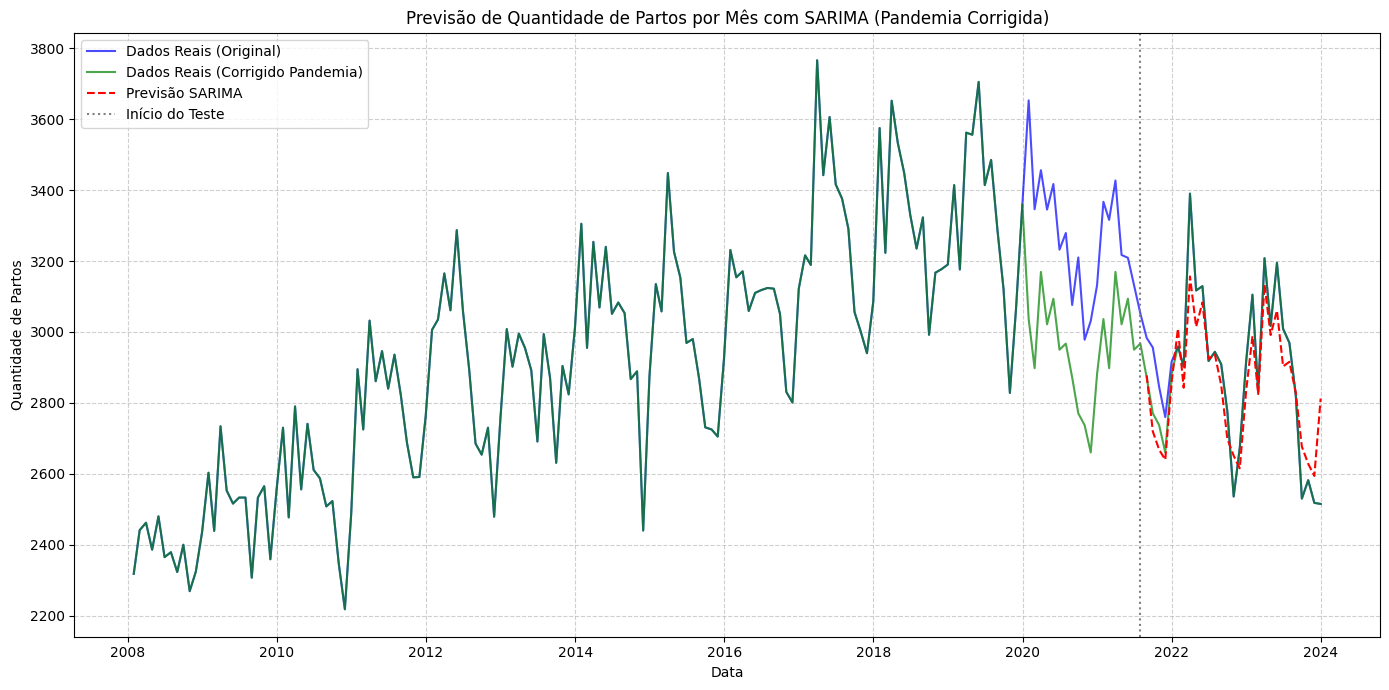


Execução do modelo preditivo concluída.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import os

# --- Configurações ---
# Caminho para o arquivo CSV de partos por dia
caminho_csv_partos = 'partos_dia.csv'
# Coluna de data no CSV de partos
coluna_data = 'DT_INTER' # Nome esperado da coluna de data
# Coluna de quantidade no CSV de partos
coluna_quantidade = 'QTD_PARTOS_NO_DIA'
# Nome do arquivo para salvar o gráfico
nome_arquivo_grafico = "preditivo_partos_mes_corrigido_pandemia.png" # Alterado para refletir novo ajuste

# ---------------------
# 1. Carregar e preparar os dados
# ---------------------
print(f"Carregando e preparando os dados do arquivo: {caminho_csv_partos}")
if not os.path.exists(caminho_csv_partos):
    print(f"Erro: O arquivo '{caminho_csv_partos}' não foi encontrado.")
    print("Certifique-se de que o arquivo está na mesma pasta do script.")
    exit()

df = pd.read_csv(caminho_csv_partos)

# --- Ajuste CRÍTICO: Limpar nomes das colunas ---
# Isso remove espaços em branco (ou outros caracteres invisíveis) dos nomes das colunas
# que podem causar o KeyError.
df.columns = df.columns.str.strip()
print("Nomes das colunas após limpeza:")
print(df.columns.tolist())

# Converte a coluna de data para datetime e define como índice
# O formato da data no 'partos_dia.csv' é 'YYYY-MM-DD', então usamos '%Y-%m-%d'
df[coluna_data] = pd.to_datetime(df[coluna_data], format='%Y-%m-%d', errors='coerce')
df = df.set_index(coluna_data).sort_index()

# Remove linhas com datas inválidas (NaT) que podem ter surgir da conversão
if coluna_quantidade in df.columns:
    df = df.dropna(subset=[coluna_quantidade])
else:
    print(f"Aviso: Coluna '{coluna_quantidade}' não encontrada para remoção de NaNs.")

# Garante que o índice (coluna de data) não tem NaNs.
# Isso é importante para séries temporais.
df = df[df.index.notna()]

# Garante que a coluna de quantidade é numérica
df[coluna_quantidade] = pd.to_numeric(df[coluna_quantidade], errors='coerce')
df = df.dropna(subset=[coluna_quantidade]) # Remove NaNs que podem ter surgido da conversão

print(f"Dados carregados. Total de registros: {len(df):,}")
print("Primeiras 5 linhas do DataFrame preparado:")
print(df.head().to_string())

# --- NOVO AJUSTE: Filtrar dados para o período até o final de 2023 (excluindo 2024) ---
print("\nFiltrando dados para o período até o final de 2023 (excluindo 2024)...")
df = df.loc['2008-01-01':'2023-12-31'] # Define o limite superior para 31 de dezembro de 2023
print(f"Dados filtrados. Total de registros: {len(df):,}")

# --- Agrupar dados por mês ---
print("\nAgrupando dados por mês...")
# Resample 'M' para o final do mês e soma as quantidades
df_mensal = df[coluna_quantidade].resample('M').sum().to_frame()
df_mensal.columns = [coluna_quantidade] # Renomeia a coluna após resample
print(f"Dados agrupados por mês. Total de registros mensais: {len(df_mensal):,}")
print("Primeiras 5 linhas do DataFrame mensal:")
print(df_mensal.head().to_string())

# --- NOVO AJUSTE: Substituir 2020 e 2021 pelas médias dos meses anteriores ---
print("\nCorrigindo dados de 2020 e 2021 com a média dos anos anteriores (pré-pandemia)...")
df_corrigido = df_mensal.copy()

# Cria colunas de mês e ano para facilitar a correção
df_corrigido['mes'] = df_corrigido.index.month
df_corrigido['ano'] = df_corrigido.index.year

# Para cada mês de 2020 e 2021, calcula a média dos mesmos meses de anos anteriores a 2020
for ano_pandemia in [2020, 2021]:
    for mes_num in range(1, 13):
        # Calcula a média dos meses correspondentes de anos ANTES da pandemia (ex: 2008-2019)
        media_anos_anteriores = df_corrigido[
            (df_corrigido['mes'] == mes_num) &
            (df_corrigido['ano'] < 2020)
        ][coluna_quantidade].mean()

        # Substitui o valor original pela média calculada, se a média não for NaN
        if not np.isnan(media_anos_anteriores):
            df_corrigido.loc[
                (df_corrigido['ano'] == ano_pandemia) &
                (df_corrigido['mes'] == mes_num),
                coluna_quantidade
            ] = media_anos_anteriores
        else:
            print(f"Aviso: Não há dados anteriores a 2020 para o mês {mes_num} do ano {ano_pandemia} para calcular a média. Mantendo valor original ou NaN.")

# Remove as colunas auxiliares 'mes' e 'ano' antes de prosseguir com o modelo
df = df_corrigido.drop(columns=['mes', 'ano'])
print("Dados de 2020 e 2021 ajustados.")
print("Primeiras 5 linhas do DataFrame após correção da pandemia:")
print(df.head().to_string())
print("Últimas 5 linhas do DataFrame após correção da pandemia:")
print(df.tail().to_string())


# ---------------------
# 3. Dividir treino e teste
# ---------------------
# Usar os últimos 12 meses (ou um período sazonal) como conjunto de teste é uma boa prática
# para séries temporais com sazonalidade mensal (12).
# Se a série for diária, o período de teste pode ser os últimos 30, 60 ou 90 dias, por exemplo.
# Para este exemplo, vamos usar os últimos 12 meses como teste.
# Ajuste conforme a granularidade da sua série e o período que deseja prever.

# NOVO AJUSTE: Manter a base de treino em 85%
split_index = int(len(df) * 0.85) # Mantido em 85%
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

print(f"\nDivisão Treino/Teste:")
print(f"Tamanho do conjunto de treino: {len(df_train):,} registros")
print(f"Tamanho do conjunto de teste: {len(df_test):,} registros")
print(f"Período de treino: {df_train.index.min().strftime('%Y-%m-%d')} a {df_train.index.max().strftime('%Y-%m-%d')}")
print(f"Período de teste: {df_test.index.min().strftime('%Y-%m-%d')} a {df_test.index.max().strftime('%Y-%m-%d')}")


# ---------------------
# 4. Teste de estacionariedade (ADF - Augmented Dickey-Fuller)
# ---------------------
# É importante que a série seja estacionária para modelos SARIMA.
# Se p-value > 0.05, a série não é estacionária e pode precisar de diferenciação (d ou D).
def test_stationarity(timeseries):
    print("\nRealizando Teste de Estacionariedade (Augmented Dickey-Fuller):")
    result = adfuller(timeseries.dropna()) # .dropna() para lidar com possíveis NaNs
    print('Estatística ADF:', result[0])
    print('p-value:', result[1])
    print('Valores Críticos:', result[4])
    if result[1] <= 0.05:
        print("A série é estacionária (p-value <= 0.05).")
    else:
        print("A série não é estacionária (p-value > 0.05). Pode ser necessária diferenciação.")

test_stationarity(df_train[coluna_quantidade])

# ---------------------
# 5. Ajustar o modelo SARIMA
# ---------------------
# Os parâmetros (p,d,q)(P,D,Q,s) são cruciais.
# (p,d,q): ordem não sazonal (AR, I, MA)
# (P,D,Q,s): ordem sazonal (AR, I, MA, período sazonal)

# Parâmetros para dados MENSAIS (s=12)
# Mantendo os últimos parâmetros que você testou: (p=1, d=1, q=1) e (P=1, D=1, Q=2, s=12)
order = (1, 1, 1)
seasonal_order = (1, 1, 2, 12)

# Se o p-value do teste ADF foi alto, considere aumentar 'd' em 'order' ou 'D' em 'seasonal_order'.
# enforce_stationarity e enforce_invertibility podem ser True se a série for bem comportada.
# Se o modelo falhar, tente False primeiro e depois True após encontrar bons parâmetros.
model = SARIMAX(
    df_train[coluna_quantidade],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False, # Pode ser True se a série for estacionária ou diferenciada
    enforce_invertibility=False # Pode ser True
)

print(f"\nAjustando o modelo SARIMA com ordem {order} e ordem sazonal {seasonal_order}...")
try:
    model_fit = model.fit(disp=False) # disp=False para suprimir a saída de otimização
    print("Modelo ajustado com sucesso!")
    print(model_fit.summary())
except Exception as e:
    print(f"Erro ao ajustar o modelo SARIMA: {e}")
    print("Considere ajustar os parâmetros (order, seasonal_order) ou os flags enforce_stationarity/enforce_invertibility.")
    exit()

# ---------------------
# 6. Previsão
# ---------------------
print(f"\nRealizando previsão para os próximos {len(df_test)} passos...")
forecast = model_fit.forecast(steps=len(df_test))
forecast_df = pd.DataFrame({coluna_quantidade: forecast}, index=df_test.index)

print("Previsão concluída. Primeiras 5 previsões:")
print(forecast_df.head().to_string())

# ---------------------
# 7. Avaliação do modelo
# ---------------------
print("\nAvaliação do modelo:")

# Garante que não há NaNs nos dados reais ou nas previsões antes de calcular as métricas.
# Isso é crucial para evitar o ValueError: Input contains NaN.
df_test_cleaned = df_test[coluna_quantidade].dropna()
forecast_cleaned = forecast_df[coluna_quantidade].dropna()

# Alinha os índices para garantir que estamos comparando as mesmas datas
# Isso é importante se a remoção de NaNs resultou em índices diferentes
common_index = df_test_cleaned.index.intersection(forecast_cleaned.index)
df_test_final = df_test_cleaned.loc[common_index]
forecast_final = forecast_cleaned.loc[common_index]

if len(df_test_final) == 0:
    print("Erro: Não há dados válidos para avaliação após a remoção de NaNs.")
    print("Verifique a qualidade dos dados de teste e das previsões.")
else:
    mae = mean_absolute_error(df_test_final, forecast_final)
    rmse = np.sqrt(mean_squared_error(df_test_final, forecast_final))
    print(f"MAE (Mean Absolute Error): {mae:.2f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

    def smape(y_true, y_pred):
        # SMAPE (Symmetric Mean Absolute Percentage Error)
        # Adiciona epsilon para evitar divisão por zero
        return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + np.finfo(float).eps))

    s = smape(df_test_final, forecast_final)
    print(f"SMAPE (Symmetric Mean Absolute Percentage Error): {s:.2f}%")

# ---------------------
# 8. Gráfico final
# ---------------------
plt.figure(figsize=(14, 7))

# Plota os dados reais (treino e teste)
plt.plot(df_mensal.index, df_mensal[coluna_quantidade], label='Dados Reais (Original)', color='blue', alpha=0.7)
plt.plot(df.index, df[coluna_quantidade], label='Dados Reais (Corrigido Pandemia)', color='green', alpha=0.7)


# Plota a previsão
plt.plot(forecast_df.index, forecast_df[coluna_quantidade], label='Previsão SARIMA', color='red', linestyle='dashed')

# Linha para indicar o ponto de divisão treino/teste
plt.axvline(df_train.index.max(), color='grey', linestyle=':', label='Início do Teste')

plt.legend()
plt.xlabel('Data')
plt.ylabel('Quantidade de Partos')
plt.title('Previsão de Quantidade de Partos por Mês com SARIMA (Pandemia Corrigida)') # Título atualizado
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Salva o gráfico
plt.savefig(nome_arquivo_grafico, dpi=300, bbox_inches='tight')
print(f"\nGráfico salvo como: {nome_arquivo_grafico}")
plt.show()

print("\nExecução do modelo preditivo concluída.")


Carregando e preparando os dados do arquivo: transplantes_diarios_contagem.csv
Nomes das colunas após limpeza:
['DT_INTER', 'QTD_TRANSPLANTES_NO_DIA']
Dados carregados. Total de registros: 3,579
Primeiras 5 linhas do DataFrame preparado:
            QTD_TRANSPLANTES_NO_DIA
DT_INTER                           
2007-11-03                        1
2007-11-07                        1
2007-11-11                        3
2007-11-13                        1
2007-11-14                        1

Filtrando dados para o período até o final de 2023 (excluindo 2024)...
Dados filtrados. Total de registros: 3,367

Agrupando dados por mês (resample para somar contagens diárias em mensais)...
Dados agrupados por mês. Total de registros mensais: 194
Primeiras 5 linhas do DataFrame mensal:
            QTD_TRANSPLANTES_NO_DIA
DT_INTER                           
2007-11-30                       18
2007-12-31                       21
2008-01-31                       34
2008-02-29                       19
200

/tmp/ipykernel_9893/1344031893.py:69: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensal = df[coluna_quantidade].resample('M').sum().to_frame()
/tmp/ipykernel_9893/1344031893.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '42.916666666666664' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_corrigido.loc[


Modelo ajustado com sucesso!
                                        SARIMAX Results                                        
Dep. Variable:                 QTD_TRANSPLANTES_NO_DIA   No. Observations:                  164
Model:             SARIMAX(1, 1, 1)x(1, 1, [1, 2], 12)   Log Likelihood                -445.053
Date:                                 Sat, 19 Jul 2025   AIC                            902.106
Time:                                         15:38:25   BIC                            919.075
Sample:                                     11-30-2007   HQIC                           909.000
                                          - 06-30-2021                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0940      0.111      0.847  

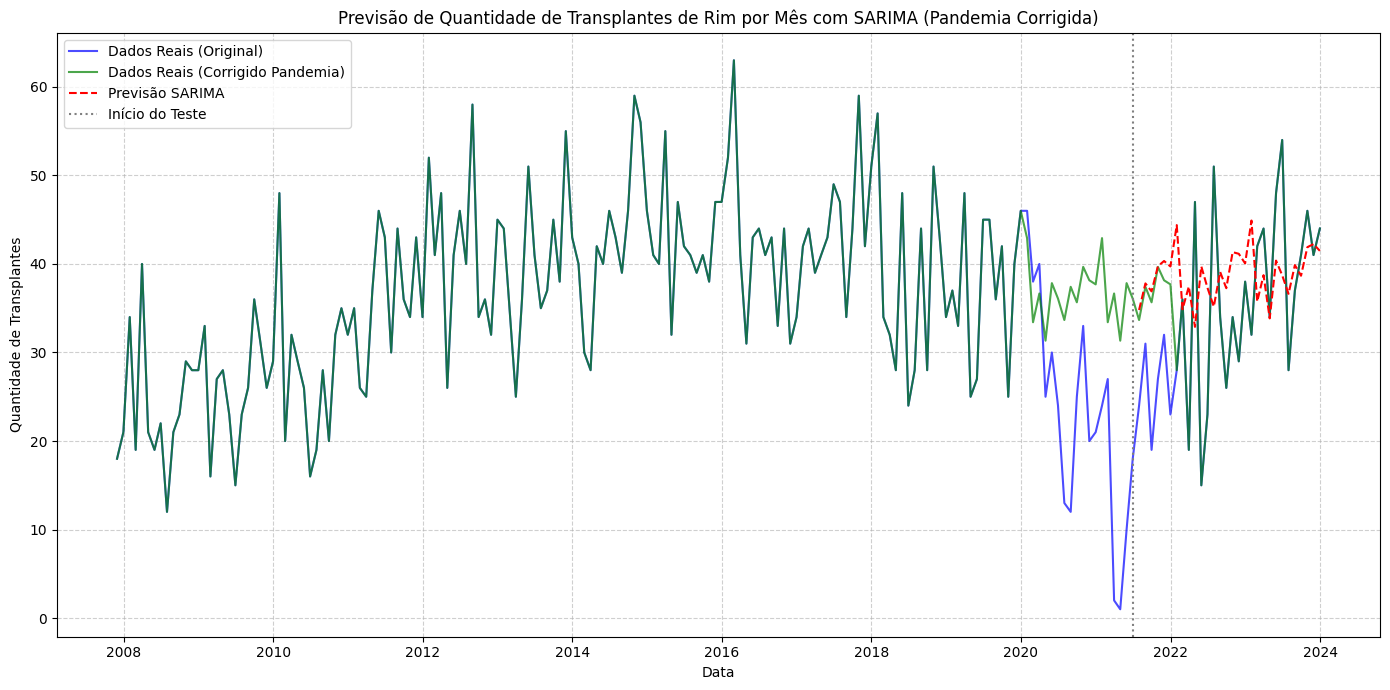


Execução do modelo preditivo concluída.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import os

# --- Configurações ---
# Caminho para o arquivo CSV de transplantes diários (que contém dados mensais)
caminho_csv_dados = 'transplantes_diarios_contagem.csv' # Alterado para o arquivo de contagem de transplantes
# Coluna de data no CSV
coluna_data = 'DT_INTER' # Nome da coluna de data no transplantes_diarios_contagem.csv
# Coluna de quantidade no CSV
coluna_quantidade = 'QTD_TRANSPLANTES_NO_DIA' # Nome da coluna de quantidade no transplantes_diarios_contagem.csv
# Nome do arquivo para salvar o gráfico
nome_arquivo_grafico = "preditivo_transplantes_mes_corrigido_pandemia_sem_2024.png" # Alterado para transplantes

# ---------------------
# 1. Carregar e preparar os dados
# ---------------------
print(f"Carregando e preparando os dados do arquivo: {caminho_csv_dados}")
if not os.path.exists(caminho_csv_dados):
    print(f"Erro: O arquivo '{caminho_csv_dados}' não foi encontrado.")
    print("Certifique-se de que o arquivo está na mesma pasta do script.")
    exit()

df = pd.read_csv(caminho_csv_dados)

# --- Ajuste CRÍTICO: Limpar nomes das colunas ---
# Isso remove espaços em branco (ou outros caracteres invisíveis) dos nomes das colunas
# que podem causar o KeyError.
df.columns = df.columns.str.strip()
print("Nomes das colunas após limpeza:")
print(df.columns.tolist())

# Converte a coluna de data para datetime e define como índice
# O formato da data no 'transplantes_diarios_contagem.csv' é 'YYYY-MM-DD', então usamos '%Y-%m-%d'
df[coluna_data] = pd.to_datetime(df[coluna_data], format='%Y-%m-%d', errors='coerce')
df = df.set_index(coluna_data).sort_index()

# Remove linhas com datas inválidas (NaT) que podem ter surgido da conversão
if coluna_quantidade in df.columns:
    df = df.dropna(subset=[coluna_quantidade])
else:
    print(f"Aviso: Coluna '{coluna_quantidade}' não encontrada para remoção de NaNs.")

# Garante que o índice (coluna de data) não tem NaNs.
# Isso é importante para séries temporais.
df = df[df.index.notna()]

# Garante que a coluna de quantidade é numérica
df[coluna_quantidade] = pd.to_numeric(df[coluna_quantidade], errors='coerce')
df = df.dropna(subset=[coluna_quantidade]) # Remove NaNs que podem ter surgido da conversão

print(f"Dados carregados. Total de registros: {len(df):,}")
print("Primeiras 5 linhas do DataFrame preparado:")
print(df.head().to_string())

# --- Filtrar dados para o período até o final de 2023 (excluindo 2024) ---
print("\nFiltrando dados para o período até o final de 2023 (excluindo 2024)...")
df = df.loc[:'2023-12-31'] # Define o limite superior para 31 de dezembro de 2023
print(f"Dados filtrados. Total de registros: {len(df):,}")

# --- Agrupar dados por mês ---
# O arquivo 'transplantes_diarios_contagem.csv' já é uma contagem diária.
# Precisamos reamostrar para mensal.
print("\nAgrupando dados por mês (resample para somar contagens diárias em mensais)...")
df_mensal = df[coluna_quantidade].resample('M').sum().to_frame()
df_mensal.columns = [coluna_quantidade] # Renomeia a coluna após resample
print(f"Dados agrupados por mês. Total de registros mensais: {len(df_mensal):,}")
print("Primeiras 5 linhas do DataFrame mensal:")
print(df_mensal.head().to_string())

# --- Substituir 2020 e 2021 pelas médias dos meses anteriores (correção pandemia) ---
print("\nCorrigindo dados de 2020 e 2021 com a média dos anos anteriores (pré-pandemia)...")
df_corrigido = df_mensal.copy()

# Cria colunas de mês e ano para facilitar a correção
df_corrigido['mes'] = df_corrigido.index.month
df_corrigido['ano'] = df_corrigido.index.year

# Para cada mês de 2020 e 2021, calcula a média dos mesmos meses de anos anteriores a 2020
for ano_pandemia in [2020, 2021]:
    for mes_num in range(1, 13):
        # Calcula a média dos meses correspondentes de anos ANTES da pandemia (ex: 2008-2019)
        media_anos_anteriores = df_corrigido[
            (df_corrigido['mes'] == mes_num) &
            (df_corrigido['ano'] < 2020)
        ][coluna_quantidade].mean()

        # Substitui o valor original pela média calculada, se a média não for NaN
        if not np.isnan(media_anos_anteriores):
            df_corrigido.loc[
                (df_corrigido['ano'] == ano_pandemia) &
                (df_corrigido['mes'] == mes_num),
                coluna_quantidade
            ] = media_anos_anteriores
        else:
            print(f"Aviso: Não há dados anteriores a 2020 para o mês {mes_num} do ano {ano_pandemia} para calcular a média. Mantendo valor original ou NaN.")

# Remove as colunas auxiliares 'mes' e 'ano' antes de prosseguir com o modelo
df = df_corrigido.drop(columns=['mes', 'ano'])
print("Dados de 2020 e 2021 ajustados.")
print("Primeiras 5 linhas do DataFrame após correção da pandemia:")
print(df.head().to_string())
print("Últimas 5 linhas do DataFrame após correção da pandemia:")
print(df.tail().to_string())


# ---------------------
# 3. Dividir treino e teste
# ---------------------
# Usar os últimos 12 meses como conjunto de teste é uma boa prática
# para séries temporais com sazonalidade mensal (s=12).

# Manter a base de treino em 85%
split_index = int(len(df) * 0.85) # Mantido em 85%
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

print(f"\nDivisão Treino/Teste:")
print(f"Tamanho do conjunto de treino: {len(df_train):,} registros")
print(f"Tamanho do conjunto de teste: {len(df_test):,} registros")
print(f"Período de treino: {df_train.index.min().strftime('%Y-%m-%d')} a {df_train.index.max().strftime('%Y-%m-%d')}")
print(f"Período de teste: {df_test.index.min().strftime('%Y-%m-%d')} a {df_test.index.max().strftime('%Y-%m-%d')}")


# ---------------------
# 4. Teste de estacionariedade (ADF - Augmented Dickey-Fuller)
# ---------------------
# É importante que a série seja estacionária para modelos SARIMA.
# Se p-value > 0.05, a série não é estacionária e pode precisar de diferenciação (d ou D).
def test_stationarity(timeseries):
    print("\nRealizando Teste de Estacionariedade (Augmented Dickey-Fuller):")
    result = adfuller(timeseries.dropna()) # .dropna() para lidar com possíveis NaNs
    print('Estatística ADF:', result[0])
    print('p-value:', result[1])
    print('Valores Críticos:', result[4])
    if result[1] <= 0.05:
        print("A série é estacionária (p-value <= 0.05).")
    else:
        print("A série não é estacionária (p-value > 0.05). Pode ser necessária diferenciação.")

test_stationarity(df_train[coluna_quantidade])

# ---------------------
# 5. Ajustar o modelo SARIMA
# ---------------------
# Os parâmetros (p,d,q)(P,D,Q,s) são cruciais.
# (p,d,q): ordem não sazonal (AR, I, MA)
# (P,D,Q,s): ordem sazonal (AR, I, MA, período sazonal)

# Parâmetros para dados MENSAIS (s=12)
# Mantendo os últimos parâmetros que você testou: (p=1, d=1, q=1) e (P=1, D=1, Q=2, s=12)
order = (1, 1, 1)
seasonal_order = (1, 1, 2, 12)

# Se o p-value do teste ADF foi alto, considere aumentar 'd' em 'order' ou 'D' em 'seasonal_order'.
# enforce_stationarity e enforce_invertibility podem ser True se a série for bem comportada.
# Se o modelo falhar, tente False primeiro e depois True após encontrar bons parâmetros.
model = SARIMAX(
    df_train[coluna_quantidade],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False, # Pode ser True se a série for estacionária ou diferenciada
    enforce_invertibility=False # Pode ser True
)

print(f"\nAjustando o modelo SARIMA com ordem {order} e ordem sazonal {seasonal_order}...")
try:
    model_fit = model.fit(disp=False) # disp=False para suprimir a saída de otimização
    print("Modelo ajustado com sucesso!")
    print(model_fit.summary())
except Exception as e:
    print(f"Erro ao ajustar o modelo SARIMA: {e}")
    print("Considere ajustar os parâmetros (order, seasonal_order) ou os flags enforce_stationarity/enforce_invertibility.")
    exit()

# ---------------------
# 6. Previsão
# ---------------------
print(f"\nRealizando previsão para os próximos {len(df_test)} passos...")
forecast = model_fit.forecast(steps=len(df_test))
forecast_df = pd.DataFrame({coluna_quantidade: forecast}, index=df_test.index)

print("Previsão concluída. Primeiras 5 previsões:")
print(forecast_df.head().to_string())

# ---------------------
# 7. Avaliação do modelo
# ---------------------
print("\nAvaliação do modelo:")

# Garante que não há NaNs nos dados reais ou nas previsões antes de calcular as métricas.
# Isso é crucial para evitar o ValueError: Input contains NaN.
df_test_cleaned = df_test[coluna_quantidade].dropna()
forecast_cleaned = forecast_df[coluna_quantidade].dropna()

# Alinha os índices para garantir que estamos comparando as mesmas datas
# Isso é importante se a remoção de NaNs resultou em índices diferentes
common_index = df_test_cleaned.index.intersection(forecast_cleaned.index)
df_test_final = df_test_cleaned.loc[common_index]
forecast_final = forecast_cleaned.loc[common_index]

# --- ADIÇÃO DE DEBUGGING ---
print(f"Tamanho de df_test_cleaned: {len(df_test_cleaned)}")
print(f"Tamanho de forecast_cleaned: {len(forecast_cleaned)}")
print(f"Tamanho do common_index: {len(common_index)}")
print(f"Tamanho de df_test_final (após alinhamento): {len(df_test_final)}")
print(f"Tamanho de forecast_final (após alinhamento): {len(forecast_final)}")
# --- FIM DA ADIÇÃO DE DEBUGGING ---


if len(df_test_final) == 0:
    print("Erro: Não há dados válidos para avaliação após a remoção de NaNs e alinhamento de índices.")
    print("Verifique a qualidade dos dados de teste e das previsões.")
else:
    mae = mean_absolute_error(df_test_final, forecast_final)
    rmse = np.sqrt(mean_squared_error(df_test_final, forecast_final))
    print(f"MAE (Mean Absolute Error): {mae:.2f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

    def smape(y_true, y_pred):
        # SMAPE (Symmetric Mean Absolute Percentage Error)
        # Adiciona epsilon para evitar divisão por zero
        return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + np.finfo(float).eps))

    s = smape(df_test_final, forecast_final)
    print(f"SMAPE (Symmetric Mean Absolute Percentage Error): {s:.2f}%")

# ---------------------
# 8. Gráfico final
# ---------------------
plt.figure(figsize=(14, 7))

# Plota os dados reais (treino e teste)
plt.plot(df_mensal.index, df_mensal[coluna_quantidade], label='Dados Reais (Original)', color='blue', alpha=0.7)
plt.plot(df.index, df[coluna_quantidade], label='Dados Reais (Corrigido Pandemia)', color='green', alpha=0.7)


# Plota a previsão
plt.plot(forecast_df.index, forecast_df[coluna_quantidade], label='Previsão SARIMA', color='red', linestyle='dashed')

# Linha para indicar o ponto de divisão treino/teste
plt.axvline(df_train.index.max(), color='grey', linestyle=':', label='Início do Teste')

plt.legend()
plt.xlabel('Data')
plt.ylabel('Quantidade de Transplantes') # Alterado para Transplantes
plt.title('Previsão de Quantidade de Transplantes de Rim por Mês com SARIMA (Pandemia Corrigida)') # Título atualizado
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Salva o gráfico
plt.savefig(nome_arquivo_grafico, dpi=300, bbox_inches='tight')
print(f"\nGráfico salvo como: {nome_arquivo_grafico}")
plt.show()

print("\nExecução do modelo preditivo concluída.")
